# Gap Matching — Roster Need Scorer

Computes how well a player's individual stat profile fills the specific statistical gaps in a school's current roster, position by position.

**Feature space (gap-cos-v3 — rate/style features, see Cell 0):**

| Layer | Dims | Player source | Position weight source |
|---|---|---|---|
| Stat profile | 14 | `player_season_stats` rate/style metrics (usage, true shooting, assist/rebound/block/steal rates, FT rate, shot distribution, finishing%) | — |
| Position weights | 5 (soft) | `hoop_explorer_player_stats.pos_confidence_*`, with `barttorvik_role` → `players.position` → height-prior fallback chain |

`gap_match` in DB = soft-weighted cosine similarity between a player's scaled stat vector and a school's position-specific gap vector (`max(0, league_benchmark - roster_mean)`), summed across positions using the player's position-confidence weights, then shrunk toward a conservative baseline by a reliability score (position source, sample size, feature completeness).

**Output:** `player_team_fit_scores.gap_match` for every eligible player×school×season pair (gap-cos-v3, PR #33) — no longer limited to the pairs `scheme_fit_scorer.ipynb` pre-seeded. Scheme Fit context is preserved where it already exists.

**Prerequisites:**
- `player_clustering.ipynb` complete → `player_archetypes` populated (archetype deficit flag)
- `player_season_stats` + `hoop_explorer_player_stats` populated in DB
- `scheme_fit_scorer.ipynb` having run first is no longer required for pair coverage, but still useful — its `scheme_fit`/`breakdown` are preserved onto matching rows when present</cell>


In [1]:
# Cell 0 — Imports + Config
import os, json, warnings
from pathlib import Path
from datetime import datetime, timezone, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import psycopg2
from psycopg2.extras import execute_values
from dotenv import load_dotenv

from portalpoint.modeling import gap_matching as gm
from portalpoint.modeling.availability import sync_portal_candidate_flags
from portalpoint.modeling.io import find_repo_root, get_sync_engine

warnings.filterwarnings('ignore')
load_dotenv()

# ── paths ────────────────────────────────────────────────────────────────────
ROOT       = find_repo_root()
MODELS_DIR = ROOT / 'data' / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── config — pulled from src/portalpoint/modeling/gap_matching.py ────────────
SEASONS_IN_DATA = [2021, 2022, 2023, 2024, 2025, 2026]
CURRENT_SEASON  = max(SEASONS_IN_DATA)
SCHOOL_CHUNK_SIZE = 50  # bounds memory for the all-pairs score+write loop (Cell 7)

GAP_FEATURES = gm.GAP_FEATURES
POS_COLS  = gm.POS_COLS
POS_NAMES = gm.POS_NAMES
POS_IDX   = {p: i for i, p in enumerate(POS_NAMES)}

MIN_GAMES     = gm.MIN_GAMES
MODEL_VERSION = gm.MODEL_VERSION
W_GAP, W_SCHEME, W_ROLE, W_PROG = gm.W_GAP, gm.W_SCHEME, gm.W_ROLE, gm.W_PROG

# ── KNOWN LIMITATIONS ───────────────────────────────────────────
# gap-cos-v2 (2026-06-21, Issue #26): transfers table now has real rows —
#   departure filter applied below (Cell 1b), current season only. Scoped to
#   confirmed portal transfers; graduations/draft departures still count as
#   roster-resident (roster_state_features.open_minutes_by_position covers
#   that broader case separately, not wired in here).
# gap-cos-v3 (PR #33): rate/style 14-feature vector (was an 8-stat
#   mostly-result-counting vector), reliability-aware score calibration, and
#   all-pairs scoring (roster_df vs. candidate_df split in Cell 1b) — this
#   notebook is now in sync with scripts/run_gap_matching.py.
# player_school_seasons: 0 rows — roster source is player_season_stats.school_id.

print('Config loaded — seasons:', SEASONS_IN_DATA)


Config loaded — seasons: [2021, 2022, 2023, 2024, 2025, 2026]


## 1. Load Player Stats

Pulls the 14-dim rate/style stat vector from `player_season_stats` (usage, true shooting, assist/rebound/block/steal rates, FT rate, shot distribution, finishing%), joined to `players` (position, height) and LEFT JOINed to `hoop_explorer_player_stats` for soft position confidence. Filters to `games_played >= MIN_GAMES` only — missing feature values are filled via `gm.prepare_gap_features` (season medians), not dropped. Deduplicated to one row per `(player_id, season)` — mid-season transfers keep the row with more games played.

In [2]:
# Cell 1 — DB connect + load player stats with soft position weights (gap-cos-v3)
# Rate/style features — replaces the old mostly-result-counting 8-stat vector
# (ppg/rpg/apg/spg/bpg/ts%/usage%/3pt rate). No NOT NULL filters here —
# gm.prepare_gap_features fills missing values via season medians.
engine = get_sync_engine()
conn   = engine.raw_connection()

LOAD_SQL = f"""
SELECT
    pss.player_id,
    pss.school_id,
    pss.season,
    pss.games_played,
    pss.min_pct,
    p.position,
    p.height_inches,
    pss.barttorvik_role,
    pss.true_shooting_pct,
    pss.usage_rate,
    pss.assist_rate,
    pss.tov_pct,
    pss.off_reb_pct,
    pss.def_reb_pct,
    pss.block_pct,
    pss.steal_pct,
    pss.free_throw_rate,
    pss.three_point_rate,
    pss.rim_rate,
    pss.mid_range_rate,
    pss.fg3_pct,
    pss.rim_pct,
    hep.pos_confidence_pg,
    hep.pos_confidence_sg,
    hep.pos_confidence_sf,
    hep.pos_confidence_pf,
    hep.pos_confidence_c
FROM player_season_stats pss
JOIN players p ON p.id = pss.player_id
LEFT JOIN hoop_explorer_player_stats hep
    ON hep.player_id = pss.player_id AND hep.season = pss.season
WHERE pss.games_played           >= {MIN_GAMES}
"""

with conn.cursor() as cur:
    cur.execute(LOAD_SQL)
    cols = [d[0] for d in cur.description]
    df   = pd.DataFrame(cur.fetchall(), columns=cols)

# Dedup: keep row with most games_played per (player_id, season)
df = (
    df.sort_values('games_played', ascending=False)
      .drop_duplicates(subset=['player_id', 'season'], keep='first')
      .reset_index(drop=True)
)
df = gm.prepare_gap_features(df)

he_cov = df[POS_COLS].notna().all(axis=1).sum()
print(f'Loaded {len(df):,} player-season rows')
print(f'HE pos_confidence coverage: {he_cov:,}/{len(df):,} ({100*he_cov/len(df):.1f}%)')
print('\nRows per season:')
print(df['season'].value_counts().sort_index())


Loaded 27,047 player-season rows
HE pos_confidence coverage: 16,043/27,047 (59.3%)

Rows per season:
season
2021    4266
2022    4538
2023    4556
2024    4565
2025    4571
2026    4551
Name: count, dtype: int64


## 1b. Load Departures + Candidate/Roster Split (gap-cos-v2 departure rule, gap-cos-v3 scope)

`roster_df`: departure-filtered (excludes players who transferred out of a school, current season only — historical seasons' rosters are already correct as-is). Used **only** for league benchmarks + gap vector construction (Cells 3-4).

`candidate_df`: the full, unfiltered universe that actually gets scored. gap-cos-v3 scores every eligible player×school×season pair, not just the ones `scheme_fit_scorer.ipynb` pre-seeded. Mirrors `scripts/run_gap_matching.py` exactly.

In [3]:
# Cell 1b — Load departures + candidate/roster split (gap-cos-v3)
DEPARTED_SQL = """
SELECT player_id, from_school_id
FROM transfers
WHERE from_school_id IS NOT NULL
  AND portal_entry_date IS NOT NULL
  AND season = %s
"""

with conn.cursor() as cur:
    cur.execute(DEPARTED_SQL, (CURRENT_SEASON,))
    departed_pairs = {(r[0], r[1]) for r in cur.fetchall()}

print(f'Departed pairs loaded for season {CURRENT_SEASON}: {len(departed_pairs):,}')

roster_df = gm.filter_departed(df, departed_pairs, CURRENT_SEASON)
candidate_df = df.copy()
print(f'Roster rows after departure filter: {len(roster_df):,}')
print(f'Candidate rows retained for scoring: {len(candidate_df):,}')


Departed pairs loaded for season 2026: 1,251


Roster rows after departure filter: 25,796
Candidate rows retained for scoring: 27,047


## 2. Soft Position Assignment

HE `pos_confidence_pg/sg/sf/pf/c` already sums to ~1.0 and is used directly where available (~59% of rows). The remaining ~41% (no HE match) fall back to a one-hot vector from `players.position`. Both paths are renormalized to guard against rounding drift or rows with no position data at all.

In [4]:
# Cell 2 — Soft position weights + gap reliability (gap-cos-v3)
# Applied separately to roster_df (benchmark/gap-vector construction only)
# and candidate_df (full scoring universe) — mirrors run_gap_matching.py.
mask_no_he = candidate_df[POS_COLS].isna().all(axis=1)
print(f'Candidate rows with no HE position match (need fallback): {mask_no_he.sum():,}')

roster_df = gm.add_gap_reliability(gm.assign_soft_positions(roster_df))
candidate_df = gm.add_gap_reliability(gm.assign_soft_positions(candidate_df))

zero_weight = (candidate_df[POS_COLS].sum(axis=1) < 0.01).sum()
if zero_weight > 0:
    print(f'WARNING: {zero_weight} candidate rows with zero position weights — will score as 0')

print('\ncandidate_df pos_confidence sum stats after normalization:')
print(candidate_df[POS_COLS].sum(axis=1).describe().round(4))
print('\ncandidate_df position_source breakdown:')
print(candidate_df[gm.POSITION_SOURCE_COL].value_counts())


Candidate rows with no HE position match (need fallback): 11,004



candidate_df pos_confidence sum stats after normalization:
count    27047.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64

candidate_df position_source breakdown:
position_source
hoop_explorer      16043
barttorvik_role    10995
height_prior           9
Name: count, dtype: int64


## 3. League Benchmarks

For each season and position, computes the soft-weighted mean stat vector across all players — i.e. "what does an average PG/SG/SF/PF/C look like this season." This is the target every school's roster is compared against per position.

In [5]:
# Cell 3 — League benchmarks per season × position (soft-weighted, from roster_df)
benchmarks = gm.build_league_benchmarks(roster_df, SEASONS_IN_DATA)

bench_df = pd.DataFrame(
    benchmarks[CURRENT_SEASON],
    index=POS_NAMES,
    columns=GAP_FEATURES,
).round(2)
print(f'League benchmark ({CURRENT_SEASON}) — weighted mean stats per position:')
print(bench_df.to_string())


League benchmark (2026) — weighted mean stats per position:
    usage_rate  true_shooting_pct  assist_rate  tov_pct_inverse  off_reb_pct  def_reb_pct  block_pct  steal_pct  free_throw_rate  three_point_rate  rim_rate  mid_range_rate  fg3_pct  rim_pct
PG       19.35              49.51        19.74            81.64         2.41         8.61       0.60       2.37            36.02              0.48      0.29            0.22     0.31     0.49
SG       18.02              51.40        11.41            83.70         3.24        10.43       0.91       1.93            30.30              0.52      0.30            0.18     0.31     0.55
SF       17.87              52.26         9.05            83.64         5.63        13.30       1.60       1.72            35.14              0.41      0.40            0.18     0.29     0.59
PF       17.58              50.07         8.44            82.77         6.97        14.87       2.57       1.39            34.22              0.40      0.40            0.19    

## 4. Roster Gap Vectors

For each school × season × position, computes the soft-weighted mean stat vector of players currently on that roster, then takes `max(0, benchmark - roster_mean)`. The result is a **sparse, non-negative gap vector**: zero where the school is already at or above league average for that stat, positive where the school is short. This sparsity is intentional — it is what makes `gap_match` discriminate much more sharply than `scheme_fit` (see Section 8).

Also tracks `depth` (effective player-equivalents) per position for the `position_depth_score` breakdown field.

In [6]:
# Cell 4 — Roster composition + gap vectors per school × season × position (from roster_df)
gap_data = gm.build_roster_gap_vectors(roster_df, benchmarks, SEASONS_IN_DATA)
for season in SEASONS_IN_DATA:
    print(f'Season {season}: gap vectors built for {len(gap_data[season])} schools')

# Spot check: current season, first school — print gap by position
sample_sid = list(gap_data[CURRENT_SEASON].keys())[0]
sample_gv  = gap_data[CURRENT_SEASON][sample_sid]['gap_vecs']
print(f'\nSample gap vectors (school_id={sample_sid}, season={CURRENT_SEASON}):')
print(pd.DataFrame(sample_gv, index=POS_NAMES, columns=GAP_FEATURES).round(2))


Season 2021: gap vectors built for 346 schools
Season 2022: gap vectors built for 358 schools
Season 2023: gap vectors built for 363 schools
Season 2024: gap vectors built for 362 schools
Season 2025: gap vectors built for 364 schools
Season 2026: gap vectors built for 365 schools

Sample gap vectors (school_id=22, season=2026):
    usage_rate  true_shooting_pct  assist_rate  tov_pct_inverse  off_reb_pct  \
PG        0.00                0.0         0.38             8.63         0.00   
SG        0.00                0.0         2.45             0.00         0.26   
SF        0.51                0.0         0.00             0.00         0.41   
PF        0.15                0.0         0.00             0.00         0.00   
C         0.00                0.0         0.00             0.00         0.00   

    def_reb_pct  block_pct  steal_pct  free_throw_rate  three_point_rate  \
PG         0.00       0.25       0.00             0.00               0.0   
SG         0.13       0.12       0.0

## 5. Archetype Enrichment

Pulls Model 1 (`player_archetypes`) cluster assignments and flags, per school × season, the top-2 archetype clusters the school is most under-represented in vs. league average. A player whose archetype matches one of those deficit clusters gets `archetype_needed=True` in the breakdown — a categorical signal alongside the continuous `gap_match` score.

In [7]:
# Cell 5 — Archetype enrichment (merged into both roster_df and candidate_df)
conn.rollback()

ARCH_SQL = 'SELECT player_id, season, archetype_id, archetype_label FROM player_archetypes'
with conn.cursor() as cur:
    cur.execute(ARCH_SQL)
    arch_df = pd.DataFrame(cur.fetchall(), columns=['player_id', 'season', 'archetype_id', 'archetype_label'])

print(f'Loaded {len(arch_df):,} player_archetype rows')
print(f'Unique archetypes:\n{arch_df.groupby("archetype_id")["archetype_label"].first().sort_index()}')

roster_df = roster_df.merge(arch_df, on=['player_id', 'season'], how='left')
candidate_df = candidate_df.merge(arch_df, on=['player_id', 'season'], how='left')
arch_cov = candidate_df['archetype_id'].notna().sum()
print(f'\nCandidate archetype coverage: {arch_cov:,}/{len(candidate_df):,} ({100*arch_cov/len(candidate_df):.1f}%)')

N_CLUSTERS = int(candidate_df['archetype_id'].dropna().max()) + 1
print(f'N clusters (from M1): {N_CLUSTERS}')

arch_deficit = gm.build_archetype_deficits(roster_df, SEASONS_IN_DATA)
total_school_seasons = sum(len(v) for v in arch_deficit.values())
print(f'Archetype deficit computed for {total_school_seasons:,} school-seasons')


Loaded 18,770 player_archetype rows
Unique archetypes:
archetype_id
0                   Test Archetype
1    High-Usage Frontcourt Creator
2          Skilled Stretch Forward
3                 Post Scoring Big
4          Two-Way Perimeter Guard
5         Pressure Connector Guard
6         Active Connector Forward
7             Two-Way Spacing Wing
8                Interior Star Big
Name: archetype_label, dtype: object

Candidate archetype coverage: 18,770/27,047 (69.4%)
N clusters (from M1): 9


Archetype deficit computed for 2,158 school-seasons


## 6. Feature Scaling

Fits one `StandardScaler` on the full pooled player population (all seasons) and applies it identically to player stat vectors and gap vectors, so cosine similarity operates in a consistent, unit-variance space. Gap vectors are pre-scaled here once rather than per-pair.

In [8]:
# Cell 6 — Fit StandardScaler on candidate_df (full universe) + pre-scale gap tensors
scaler = gm.fit_gap_scaler(candidate_df)
print(f'Scaler fitted on {len(candidate_df):,} player-season rows')
print('Feature means:', dict(zip(GAP_FEATURES, scaler.mean_.round(2))))

gap_scaled = gm.prescale_gap_tensors(gap_data, scaler, SEASONS_IN_DATA)
print('Gap tensors scaled ✓')


Scaler fitted on 27,047 player-season rows
Feature means: {'usage_rate': np.float64(18.35), 'true_shooting_pct': np.float64(50.82), 'assist_rate': np.float64(10.88), 'tov_pct_inverse': np.float64(81.66), 'off_reb_pct': np.float64(5.28), 'def_reb_pct': np.float64(12.98), 'block_pct': np.float64(1.92), 'steal_pct': np.float64(1.76), 'free_throw_rate': np.float64(34.8), 'three_point_rate': np.float64(0.37), 'rim_rate': np.float64(0.39), 'mid_range_rate': np.float64(0.23), 'fg3_pct': np.float64(0.26), 'rim_pct': np.float64(0.56)}
Gap tensors scaled ✓


## 7. Score + Write All Pairs (gap-cos-v3)

Vectorized per season: builds `P` (players × 14), `G` (schools × 5 positions × 14), computes cosine similarity between every player and every (school, position) gap vector in one `cosine_similarity` call, then collapses the position axis with the player's soft position weights and shrinks toward baseline by reliability. Scores **every eligible** player×school×season pair — no longer limited to the pairs `scheme_fit_scorer.ipynb` pre-seeded — while preserving Scheme Fit context where it already exists.

Processed in school-id chunks of `SCHOOL_CHUNK_SIZE` per season and upserted chunk-by-chunk: all-pairs writes ~9.7M rows across 2021-2026, too large to hold as a single in-memory `records` list or DataFrame. This mirrors `scripts/run_gap_matching.py` exactly, including the incremental mean/std accumulation used for MLflow logging (Cell 11) instead of building one big results DataFrame.

In [ ]:
# Cell 7 — Per-season, per-school-chunk score+write loop (gap-cos-v3)
# Scheme Fit context is loaded per chunk (gm.load_existing_scheme_context),
# not preloaded for the whole table — Scheme Fit went all-pairs (scheme-cos-v3,
# ~9.6M rows), and preloading all of it into one python dict up front took
# ~64 minutes at that scale. Per-chunk keeps each query scoped to
# (season, school_batch) and uses the ix_fit_scores_school_season_candidate index.
total_records = 0
total_upserted = 0
gap_sum = 0.0
gap_sq_sum = 0.0
conn.rollback()

for season in SEASONS_IN_DATA:
    school_ids = sorted(gap_scaled[season].keys())
    season_records = 0
    season_upserted = 0
    for start in range(0, len(school_ids), SCHOOL_CHUNK_SIZE):
        school_batch = school_ids[start:start + SCHOOL_CHUNK_SIZE]
        existing = gm.load_existing_scheme_context(engine, season, school_batch)
        records = gm.score_gap_matches(
            candidate_df, scaler, gap_scaled, gap_data, arch_deficit, existing,
            [season], school_ids=school_batch,
        )
        if not records:
            continue
        gap_values = np.fromiter((r[3] for r in records), dtype=np.float64, count=len(records))
        total_records += len(records)
        season_records += len(records)
        gap_sum += float(gap_values.sum())
        gap_sq_sum += float(np.square(gap_values).sum())
        upserted = gm.upsert_gap_scores(engine, records)
        total_upserted += upserted
        season_upserted += upserted
    print(f'Season {season}: scored={season_records:,} upserted={season_upserted:,}')

print(f'\nTotal records scored: {total_records:,}')
print(f'Total rows upserted to player_team_fit_scores: {total_upserted:,}')

if total_records == 0:
    raise RuntimeError('No gap matching records were scored')
mean_gap = gap_sum / total_records
std_gap = float(np.sqrt(max(gap_sq_sum / total_records - mean_gap * mean_gap, 0.0)))
print(f'Mean gap_match: {mean_gap:.2f}  Std: {std_gap:.2f}')


## 8. Validation

`gap_match` is expected to look very different from `scheme_fit`: low mean, high standard deviation, right-skewed. This is correct — most player×school pairs have low gap alignment (the player offers what the school already has), while high scores (80+) flag genuine, specific roster need. Compare `std` against `scheme_fit`'s `std` as the discrimination check, not the means.

Queried from the DB rather than the in-memory `records` list (gap-cos-v3 writes ~9.7M rows total — too large to plot directly). Per-season stats are exact aggregate SQL; the histogram uses a random sample of the current season.

=== Per-season gap_match stats (queried from DB) ===
season 2021: n=1,476,036 mean=14.59 std=12.57 min=0.00 max=89.25
season 2022: n=1,624,604 mean=14.68 std=13.46 min=0.00 max=92.53
season 2023: n=1,653,828 mean=14.56 std=13.41 min=0.00 max=94.03
season 2024: n=1,652,530 mean=14.81 std=13.68 min=0.00 max=90.93
season 2025: n=1,663,844 mean=15.02 std=13.89 min=0.00 max=90.55
season 2026: n=1,661,115 mean=15.78 std=14.65 min=0.00 max=91.97


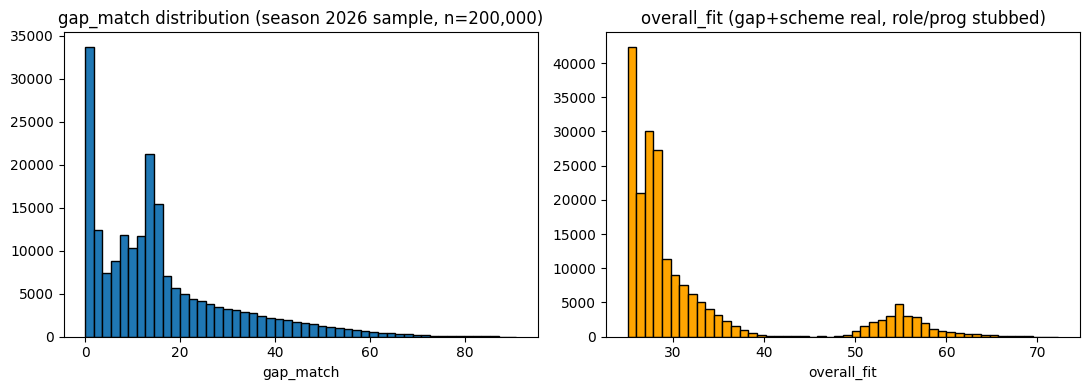


Top 5 schools by mean gap_match (2026):
  school_id=248: 25.45
  school_id=244: 24.64
  school_id=350: 23.82
  school_id=301: 23.79
  school_id=242: 23.48



Score spread comparison (std):
  gap_match std (all seasons, from Cell 7 accumulation): 13.65
  scheme_fit std (existing Scheme Fit context rows):     7.22


In [10]:
# Cell 8 — Validation (DB-query based — gap-cos-v3 all-pairs is too large for an in-memory DataFrame)
conn.rollback()

with conn.cursor() as cur:
    cur.execute("""
        SELECT season,
               COUNT(*) AS n,
               AVG(gap_match) AS mean_gap,
               STDDEV(gap_match) AS std_gap,
               MIN(gap_match) AS min_gap,
               MAX(gap_match) AS max_gap
        FROM player_team_fit_scores
        WHERE season = ANY(%s) AND model_version = %s
        GROUP BY season ORDER BY season
    """, (SEASONS_IN_DATA, MODEL_VERSION))
    season_stats = cur.fetchall()

print('=== Per-season gap_match stats (queried from DB) ===')
for r in season_stats:
    print(f'season {r[0]}: n={r[1]:,} mean={r[2]:.2f} std={r[3]:.2f} min={r[4]:.2f} max={r[5]:.2f}')

with conn.cursor() as cur:
    cur.execute("""
        SELECT gap_match, overall_fit
        FROM player_team_fit_scores
        WHERE season = %s AND model_version = %s
        ORDER BY random() LIMIT 200000
    """, (CURRENT_SEASON, MODEL_VERSION))
    sample = cur.fetchall()
sample_df = pd.DataFrame(sample, columns=['gap_match', 'overall_fit'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(sample_df['gap_match'], bins=50, edgecolor='black')
axes[0].set_title(f'gap_match distribution (season {CURRENT_SEASON} sample, n={len(sample_df):,})')
axes[0].set_xlabel('gap_match')
axes[1].hist(sample_df['overall_fit'], bins=50, edgecolor='black', color='orange')
axes[1].set_title('overall_fit (gap+scheme real, role/prog stubbed)')
axes[1].set_xlabel('overall_fit')
plt.tight_layout()
plt.show()

with conn.cursor() as cur:
    cur.execute("""
        SELECT school_id, AVG(gap_match) AS avg_gap
        FROM player_team_fit_scores
        WHERE season = %s AND model_version = %s
        GROUP BY school_id ORDER BY avg_gap DESC LIMIT 5
    """, (CURRENT_SEASON, MODEL_VERSION))
    top_gap = cur.fetchall()
print(f'\nTop 5 schools by mean gap_match ({CURRENT_SEASON}):')
for sid, avg_gap in top_gap:
    print(f'  school_id={sid}: {avg_gap:.2f}')

existing_scheme_std = float(pd.Series([r[3] for r in existing_rows]).std())
print(f'\nScore spread comparison (std):')
print(f'  gap_match std (all seasons, from Cell 7 accumulation): {std_gap:.2f}')
print(f'  scheme_fit std (existing Scheme Fit context rows):     {existing_scheme_std:.2f}')


## 9. Flag Sync + Verification

The upsert itself already happened incrementally per school-chunk in Cell 7 — gap-cos-v3's ~9.7M total rows can't be upserted in one shot the way the old M3-scoped ~1.3M-row write could. This cell re-derives `is_portal_candidate` from `transfer_portal_events` (only flips false → true, safe to rerun) and prints the same DB verification query as before.

In [11]:
# Cell 9 — Flag sync + verification
# Upsert already happened incrementally per school-chunk in Cell 7.
conn.rollback()

flagged = sync_portal_candidate_flags(engine, SEASONS_IN_DATA)
for season, count in flagged.items():
    print(f'Season {season}: is_portal_candidate flagged on {count:,} rows')

with conn.cursor() as cur:
    cur.execute("""
        SELECT season,
               COUNT(*)                            AS n,
               ROUND(AVG(gap_match)::numeric, 2)   AS avg_gap,
               ROUND(AVG(scheme_fit)::numeric, 2)  AS avg_scheme,
               ROUND(AVG(overall_fit)::numeric, 2) AS avg_overall,
               COUNT(*) FILTER (WHERE gap_match IS NOT NULL) AS gap_populated
        FROM player_team_fit_scores
        GROUP BY season ORDER BY season
    """)
    rows = cur.fetchall()

print('\nDB verification:')
print(f'{"season":>8} {"n":>10} {"avg_gap":>10} {"avg_scheme":>12} {"avg_overall":>13} {"gap_populated":>14}')
for r in rows:
    print(f'{r[0]:>8} {r[1]:>10,} {str(r[2]):>10} {str(r[3]):>12} {str(r[4]):>13} {r[5]:>14,}')

conn.close()
print(f'\nGap Matching ({MODEL_VERSION}) complete ✓')
print('Next: wire gap_match into fit_scores.py API router')


Season 2021: is_portal_candidate flagged on 147,704 rows
Season 2022: is_portal_candidate flagged on 193,424 rows
Season 2023: is_portal_candidate flagged on 242,412 rows
Season 2024: is_portal_candidate flagged on 320,736 rows
Season 2025: is_portal_candidate flagged on 417,670 rows
Season 2026: is_portal_candidate flagged on 387,965 rows



DB verification:
  season          n    avg_gap   avg_scheme   avg_overall  gap_populated
    2021  1,476,036      14.59        13.29         31.90      1,476,036
    2022  1,624,604      14.68        12.86         31.80      1,624,604
    2023  1,653,828      14.56        12.63         31.70      1,653,828
    2024  1,652,530      14.81        12.74         31.78      1,652,530
    2025  1,663,844      15.02        12.68         31.81      1,663,844
    2026  1,661,115      15.78        12.68         31.96      1,661,115

Gap Matching (gap-cos-v3) complete ✓
Next: wire gap_match into fit_scores.py API router


## 10. MLflow Tracking

Logs params/metrics and a `GapMatchPyfunc` model artifact, mirroring `scheme_fit_scorer.ipynb` Section 7. The pyfunc artifact captures the core soft-weighted cosine metric (player stat vector vs. gap vector) for registry/drift monitoring — it does not reproduce full per-school state (benchmarks, roster composition), which lives only in this notebook's run.

In [12]:
# Cell 11 — MLflow Tracking
import mlflow
import mlflow.pyfunc
from portalpoint.modeling.mlflow_helpers import setup_mlflow, maybe_promote

EXPERIMENT    = 'gap-matching'
MODEL_NAME    = 'gap-matching-scorer'
ARTIFACT_PATH = 'gap_match_model'


class GapMatchPyfunc(mlflow.pyfunc.PythonModel):
    """Wraps the core soft-weighted gap-cosine metric for MLflow model registry.

    Input DataFrame columns: player_<feat> and gap_<feat> for each of the
    GAP_FEATURES (14-dim, gap-cos-v3). Output: list of dicts with 'gap_match'
    key (float 0-100). Captures the cosine metric only — position-weight
    blending, reliability calibration, and per-school gap-vector construction
    live in this notebook, not the registered artifact.
    """

    def predict(self, context, model_input):
        import numpy as np
        results = []
        for _, r in model_input.iterrows():
            p = np.array([r[f'player_{f}'] for f in GAP_FEATURES], dtype=np.float64)
            g = np.array([r[f'gap_{f}']    for f in GAP_FEATURES], dtype=np.float64)
            norm_p, norm_g = np.linalg.norm(p), np.linalg.norm(g)
            if norm_p == 0 or norm_g == 0:
                gm_score = 0.0
            else:
                gm_score = float(np.clip(np.dot(p, g) / (norm_p * norm_g) * 100, 0, 100))
            results.append({'gap_match': round(gm_score, 2)})
        return results


client = setup_mlflow(EXPERIMENT)

# Stats come from Cell 7's incremental accumulation, not an in-memory
# DataFrame — gap-cos-v3 all-pairs (~9.7M rows) is too large to hold as one.
_mean_gap  = mean_gap
_std_gap   = std_gap
_n_records = total_records
_n_players = int(candidate_df['player_id'].nunique())
_n_schools = int(candidate_df['school_id'].nunique())
_he_pct    = float(100 * (candidate_df[gm.POSITION_SOURCE_COL] == 'hoop_explorer').mean())

with mlflow.start_run(run_name=f'gap-match-s{CURRENT_SEASON}') as run:
    mlflow.log_params({
        'seasons':         ','.join(str(s) for s in SEASONS_IN_DATA),
        'min_games':       MIN_GAMES,
        'feature_dims':    len(GAP_FEATURES),
        'features':        ','.join(GAP_FEATURES),
        'sim_method':      'soft-weighted-cosine',
        'model_version':   MODEL_VERSION,
        'he_coverage_pct': round(_he_pct, 1),
    })
    mlflow.log_metrics({
        'mean_gap_match':    _mean_gap,
        'std_gap_match':     _std_gap,
        'n_records_written': float(_n_records),
        'n_players':         float(_n_players),
        'n_schools':         float(_n_schools),
    })

    mlflow.pyfunc.log_model(
        artifact_path=ARTIFACT_PATH,
        python_model=GapMatchPyfunc(),
    )

    run_id = run.info.run_id

result = maybe_promote(
    client, MODEL_NAME, run_id, ARTIFACT_PATH,
    metric_name='std_gap_match',
    new_value=_std_gap,
    higher_is_better=True,
)
print(f'Run ID  : {run_id}')
print(f'Registry: {result}')


c:\Users\shant\Desktop\MIDS\MIDS210-Capstone\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


2026/06/21 23:46:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/21 23:46:04 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/06/21 23:46:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Registered model 'gap-matching-scorer' already exists. Creating a new version of this model...


2026/06/21 23:46:23 WARNING mlflow.tracking._model_registry.fluent: Run with id 7ab693861ae54ea1ab7a1abc32d3245b has no artifacts at artifact path 'gap_match_model', registering model based on models:/m-30f84e41260342aa9deba900a2186957 instead


Run ID  : 7ab693861ae54ea1ab7a1abc32d3245b
Registry: staging — gap-matching-scorer v5 → Staging (Δ=-19.1%)


Created version '5' of model 'gap-matching-scorer'.
